# Classificação UrbanTrace

Este notebook utiliza o dataset **UrbanTrace: Lifestyle & Pollution Insights** para prever a variável `risk_category`, que representa o nível de risco de exposição individual à poluição.

A proposta é resolver um problema de **classificação multiclasse**, comparando modelos de aprendizado de máquina e documentando as etapas de análise exploratória, pré-processamento, treinamento e avaliação.

Ao longo do notebook, as decisões metodológicas são comentadas para deixar o processo reprodutível.

## 1. Importação das bibliotecas

As bibliotecas foram escolhidas para cobrir todo o fluxo do projeto:

- `pandas`: leitura, inspeção e preparação dos dados;
- `matplotlib`: construção das visualizações;
- `scikit-learn`: separação treino/teste, pré-processamento, treinamento e avaliação dos modelos.

In [1]:
# Path ajuda a montar caminhos de arquivo de forma compatível com diferentes sistemas operacionais.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Ferramentas de pré-processamento e modelagem do scikit-learn.
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# RANDOM_STATE garante reprodutibilidade: a mesma divisão treino/teste será gerada a cada execução.
RANDOM_STATE = 42

# Variável alvo do problema de classificação.
TARGET = 'risk_category'

# Esta coluna será usada apenas na EDA. Ela é removida da modelagem para evitar vazamento de dados.
LEAKAGE_COLUMNS = ['pollution_exposure_score']

## 2. Carregamento do dataset

O arquivo está em formato CSV e possui, segundo a descrição original, **10.000 linhas e 14 colunas**. A leitura abaixo também foi feita de forma robusta para funcionar tanto quando o notebook é aberto pela pasta raiz do projeto quanto pela pasta `notebooks`.

In [2]:
# Identifica automaticamente a raiz do projeto.
project_root = Path.cwd()
if not (project_root / 'data' / 'urban_lifestyle_impact_dataset.csv').exists():
    project_root = project_root.parent

# Carrega o CSV para um DataFrame do pandas.
dataset_path = project_root / 'data' / 'urban_lifestyle_impact_dataset.csv'
df = pd.read_csv(dataset_path)

df.head()

,daily_travel_time,vehicle_ownership,location_type,nearby_industries,green_space_access,home_air_quality,work_location_type,smoker_in_household,noise_pollution_level,use_of_air_purifiers,awareness_level,years_in_location,pollution_exposure_score,risk_category
0,54.9,NaN,Semi-Urban,1.0,Moderate,65.4,Factory,False,34.9,True,NaN,28.0,32.50,Medium
1,42.2,Public Only,Semi-Urban,5.0,High,41.8,NaN,False,89.6,False,Low,30.0,70.58,High
2,58.0,NaN,Urban,1.0,Low,65.0,Remote,False,53.6,False,Medium,26.0,41.57,Medium
3,75.5,Car,Semi-Urban,2.0,Moderate,64.4,Remote,False,27.1,False,High,22.0,43.97,Medium
4,40.3,NaN,Semi-Urban,1.0,High,52.9,Factory,True,27.2,False,Medium,24.0,38.08,Medium


In [3]:
print('Linhas:', df.shape[0])
print('Colunas:', df.shape[1])
df.info()

Linhas: 10000
Colunas: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   daily_travel_time         8876 non-null   float64
 1   vehicle_ownership         6836 non-null   object 
 2   location_type             10000 non-null  object 
 3   nearby_industries         9205 non-null   float64
 4   green_space_access        9440 non-null   object 
 5   home_air_quality          10000 non-null  float64
 6   work_location_type        9347 non-null   object 
 7   smoker_in_household       10000 non-null  bool   
 8   noise_pollution_level     10000 non-null  float64
 9   use_of_air_purifiers      10000 non-null  bool   
 10  awareness_level           8985 non-null   object 
 11  years_in_location         9480 non-null   float64
 12  pollution_exposure_score  10000 non-null  float64
 13  risk_category             10000 non-

## 3. Análise exploratória inicial

A análise exploratória dos dados, também chamada de EDA (*Exploratory Data Analysis*), tem o objetivo de entender a estrutura da base antes da modelagem. Nesta etapa verificamos:

- tamanho do dataset;
- tipos das variáveis;
- distribuição da variável alvo;
- presença de valores ausentes;
- duplicatas;
- distribuição das variáveis numéricas;
- relações lineares entre variáveis numéricas.

In [4]:
df[TARGET].value_counts()

risk_category
Medium    8587
Low       1198
High       215
Name: count, dtype: int64

In [5]:
df[TARGET].value_counts(normalize=True).mul(100).round(2)

risk_category
Medium    85.87
Low       11.98
High       2.15
Name: proportion, dtype: float64

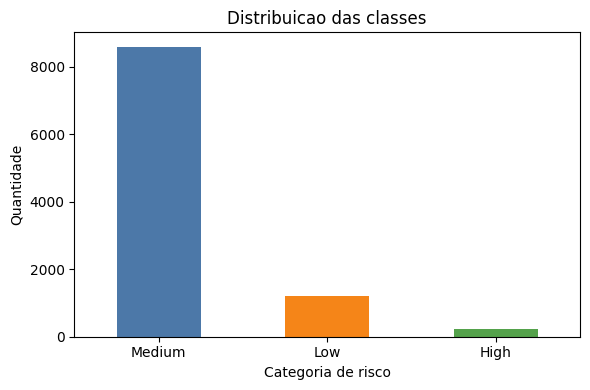

In [6]:
ax = df[TARGET].value_counts().plot(kind='bar', figsize=(6, 4), color=['#4C78A8', '#F58518', '#54A24B'])
ax.set_title('Distribuicao das classes')
ax.set_xlabel('Categoria de risco')
ax.set_ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

vehicle_ownership     3164
daily_travel_time     1124
awareness_level       1015
nearby_industries      795
work_location_type     653
green_space_access     560
years_in_location      520
dtype: int64

In [8]:
print('Duplicatas:', df.duplicated().sum())

Duplicatas: 0


In [9]:
numeric_columns = df.select_dtypes(include='number').columns
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
daily_travel_time,8876.0,45.154439,19.892298,0.00,31.6000,45.00,58.525,123.5
nearby_industries,9205.0,1.987398,1.416077,0.00,1.0000,2.00,3.000,10.0
home_air_quality,10000.0,60.114330,15.158124,0.00,49.8000,60.20,70.500,100.0
noise_pollution_level,10000.0,50.120370,20.047420,0.00,36.8000,50.10,63.600,100.0
years_in_location,9480.0,20.623312,11.558152,1.00,11.0000,21.00,31.000,40.0
pollution_exposure_score,10000.0,44.092933,12.071672,5.97,35.5175,43.69,52.010,100.0


### Visualização dos valores ausentes

O gráfico abaixo mostra quais variáveis possuem maior percentual de valores ausentes. Essa etapa é essencial porque muitos algoritmos de aprendizado de máquina não aceitam `NaN` diretamente, exigindo tratamento antes do treinamento.

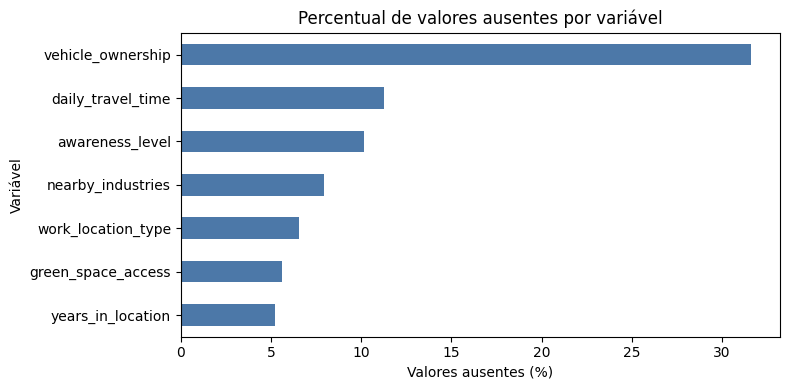

In [10]:
missing_percent = df.isna().mean().mul(100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]

ax = missing_percent.sort_values().plot(kind='barh', figsize=(8, 4), color='#4C78A8')
ax.set_title('Percentual de valores ausentes por variável')
ax.set_xlabel('Valores ausentes (%)')
ax.set_ylabel('Variável')
plt.tight_layout()
plt.show()

### Histogramas das variáveis numéricas

Os histogramas ajudam a observar distribuições, concentrações e possíveis valores extremos. Eles também indicam se uma variável possui assimetria, amplitude elevada ou concentração em determinados intervalos.

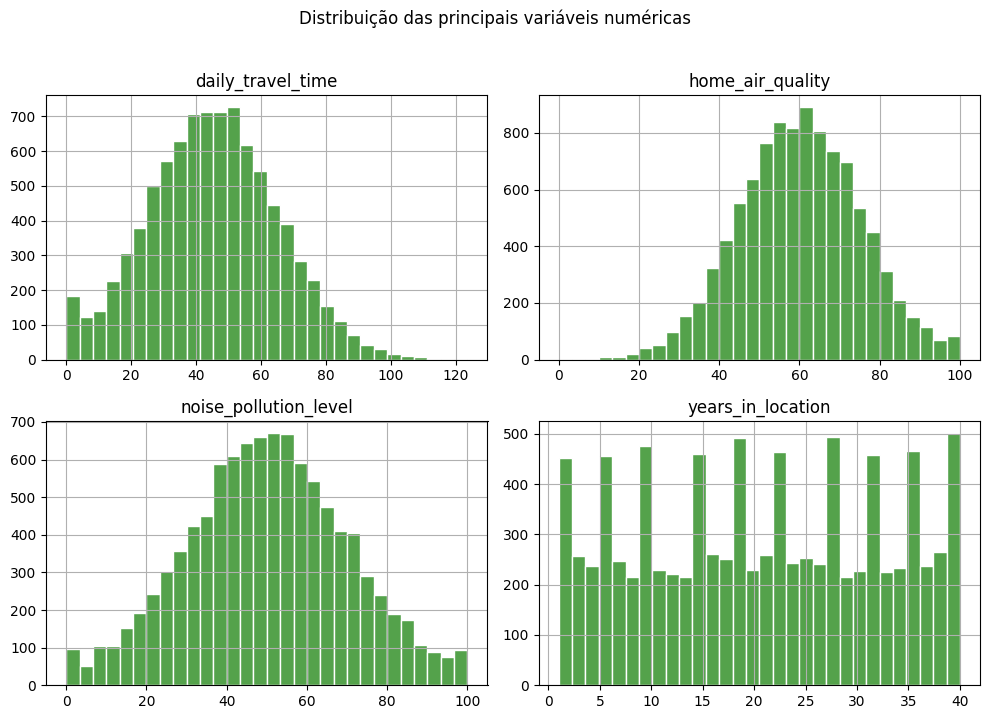

In [11]:
columns_to_plot = ['daily_travel_time', 'home_air_quality', 'noise_pollution_level', 'years_in_location']
df[columns_to_plot].hist(figsize=(10, 7), bins=30, color='#54A24B', edgecolor='white')
plt.suptitle('Distribuição das principais variáveis numéricas', y=1.02)
plt.tight_layout()
plt.show()

### Verificação de possíveis outliers

A verificação abaixo usa o critério do intervalo interquartil (IQR). Esse critério marca como possíveis outliers valores abaixo de `Q1 - 1,5 * IQR` ou acima de `Q3 + 1,5 * IQR`.

A ideia não é remover automaticamente esses registros, mas avaliar se eles são numerosos ou incoerentes com o contexto do dataset.

In [12]:
outlier_rows = []
numeric_without_target_score = df.select_dtypes(include='number').drop(columns=['pollution_exposure_score'], errors='ignore')

for column in numeric_without_target_score.columns:
    series = numeric_without_target_score[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    outlier_count = ((series < lower_limit) | (series > upper_limit)).sum()

    outlier_rows.append({
        'variavel': column,
        'limite_inferior': lower_limit,
        'limite_superior': upper_limit,
        'possiveis_outliers': outlier_count,
        'percentual': 100 * outlier_count / len(series),
        'minimo': series.min(),
        'maximo': series.max(),
    })

outliers_df = pd.DataFrame(outlier_rows)
outliers_df.round(2)

,variavel,limite_inferior,limite_superior,possiveis_outliers,percentual,minimo,maximo
0,daily_travel_time,-8.79,98.91,37,0.42,0.0,123.5
1,nearby_industries,-2.00,6.00,48,0.52,0.0,10.0
2,home_air_quality,18.75,101.55,31,0.31,0.0,100.0
3,noise_pollution_level,-3.40,103.80,0,0.00,0.0,100.0
4,years_in_location,-19.00,61.00,0,0.00,1.0,40.0


### Mapa de calor de correlação

O heatmap mostra as relações lineares entre variáveis numéricas. Ele também evidencia a proximidade de `pollution_exposure_score` com outras variáveis, mas essa coluna não será usada no modelo para evitar vazamento de dados.

Correlação não implica causalidade, mas ajuda a identificar padrões relevantes e possíveis variáveis associadas ao risco de poluição.

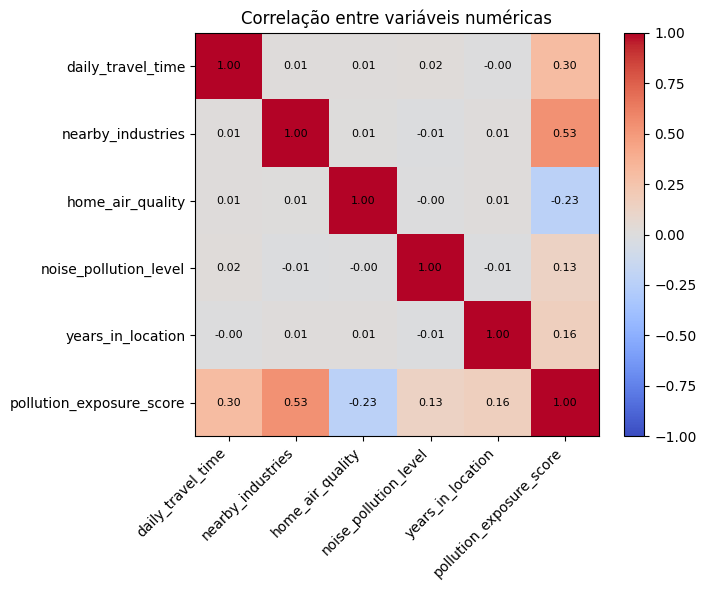

In [13]:
corr = df[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

ax.set_title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

### Principais relações numéricas

A tabela abaixo ordena as correlações com `pollution_exposure_score`, usada apenas para EDA e removida antes da modelagem. Essa análise é útil para interpretar o comportamento da base, mas não deve ser confundida com seleção automática de variáveis para o modelo.

In [14]:
corr['pollution_exposure_score'].sort_values(ascending=False)

pollution_exposure_score    1.000000
nearby_industries           0.531442
daily_travel_time           0.300786
years_in_location           0.163504
noise_pollution_level       0.125695
home_air_quality           -0.229963
Name: pollution_exposure_score, dtype: float64

## 4. Preparação dos dados

A variável alvo é `risk_category`.

A coluna `pollution_exposure_score` foi removida das variáveis de entrada porque está diretamente associada à categoria de risco. Se fosse usada como preditora, o modelo receberia uma informação muito próxima da resposta esperada, causando **vazamento de dados** (*data leakage*) e tornando a avaliação artificialmente otimista.

In [15]:
# X contem as variaveis explicativas. A variavel alvo e a coluna com risco de vazamento sao removidas.
X = df.drop(columns=[TARGET] + LEAKAGE_COLUMNS).copy()

# y contem a classe que o modelo deve aprender a prever.
y = df[TARGET].copy()

# Separacao das colunas por tipo. Isso permite aplicar tratamentos diferentes para dados numericos e categoricos.
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_features = X.select_dtypes(include='number').columns.tolist()

# Colunas categoricas e booleanas sao convertidas para object; a imputacao fica dentro do Pipeline.
X[categorical_features] = X[categorical_features].astype('object')

print('Numericas:', numeric_features)
print('Categoricas:', categorical_features)


Numericas: ['daily_travel_time', 'nearby_industries', 'home_air_quality', 'noise_pollution_level', 'years_in_location']
Categoricas: ['vehicle_ownership', 'location_type', 'green_space_access', 'work_location_type', 'smoker_in_household', 'use_of_air_purifiers', 'awareness_level']


In [16]:
# A divisão estratificada preserva a proporção das classes em treino e teste.
# Isso é importante porque a base é bastante desbalanceada.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (8000, 12)
Teste: (2000, 12)


## 5. Pipeline de pré-processamento

O pré-processamento foi organizado com `Pipeline` e `ColumnTransformer`. Essa estratégia reduz o risco de erro manual e garante que as transformações sejam ajustadas no conjunto de treino e aplicadas posteriormente ao conjunto de teste.

Tratamentos aplicados:

- variáveis numéricas: imputação pela mediana e padronização;
- variáveis categóricas: codificação por One-Hot Encoding;
- categorias desconhecidas no teste: ignoradas com `handle_unknown='ignore'`.

In [17]:
# Pipeline numerico:
# 1. SimpleImputer(strategy='median'): substitui valores ausentes pela mediana da coluna.
# 2. StandardScaler(): padroniza as variaveis para media 0 e desvio padrao 1.
numeric_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

# Pipeline categorico:
# 1. SimpleImputer(strategy='constant'): trata ausencias como uma categoria explicita.
# 2. OneHotEncoder(): transforma categorias em colunas binarias para os modelos do scikit-learn.
categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]
)

# A funcao cria um novo pre-processador para cada modelo.
# Isso evita que um modelo reutilize transformacoes ja ajustadas por outro.
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, numeric_features),
            ('cat', categorical_pipeline, categorical_features),
        ]
    )


## 6. Treinamento dos modelos

Foram comparadas três configurações de modelos:

- Regressão Logística
- Random Forest sem restrições
- Random Forest Regularizada

Como o dataset é desbalanceado, usamos `class_weight='balanced'` nos modelos. Essa configuração aumenta o peso das classes minoritárias durante o treinamento, reduzindo a tendência do modelo de favorecer apenas a classe majoritária (`Medium`).

A Regressão Logística funciona como um modelo linear de referência. A Random Forest sem restrições testa um modelo não linear mais flexível, enquanto a Random Forest Regularizada limita a profundidade e o tamanho das folhas para tentar reduzir overfitting.

In [18]:
# Cada modelo é combinado com seu próprio pipeline de pré-processamento.
# Assim, o fluxo completo pode ser treinado e avaliado de ponta a ponta.
models = {
    'Regressão Logística': Pipeline(
        steps=[
            ('preprocessor', make_preprocessor()),
            ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
        ]
    ),
    'Random Forest': Pipeline(
        steps=[
            ('preprocessor', make_preprocessor()),
            ('model', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
        ]
    ),
    'Random Forest Regularizada': Pipeline(
        steps=[
            ('preprocessor', make_preprocessor()),
            (
                'model',
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=12,
                    min_samples_split=10,
                    min_samples_leaf=10,
                    max_features='sqrt',
                    class_weight='balanced',
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

In [19]:
# Lista para armazenar as métricas comparativas dos modelos.
results = []

# Dicionário para guardar os modelos já treinados e permitir gerar matriz de confusão depois.
trained_models = {}

for name, model in models.items():
    # Ajusta o pipeline completo: pré-processamento + modelo.
    model.fit(X_train, y_train)

    # Gera previsões no treino e no teste. A comparação entre os dois ajuda a avaliar overfitting.
    train_predictions = model.predict(X_train)
    predictions = model.predict(X_test)
    trained_models[name] = model

    # Accuracy mede acertos gerais; F1 macro dá o mesmo peso para cada classe.
    # Em bases desbalanceadas, F1 macro costuma ser mais informativo que accuracy isolada.
    results.append({
        'modelo': name,
        'accuracy_treino': accuracy_score(y_train, train_predictions),
        'accuracy': accuracy_score(y_test, predictions),
        'macro_f1_treino': f1_score(y_train, train_predictions, average='macro'),
        'macro_f1': f1_score(y_test, predictions, average='macro'),
        'weighted_f1': f1_score(y_test, predictions, average='weighted'),
    })
    print('\n' + name)
    print(classification_report(y_test, predictions, zero_division=0))

results_df = pd.DataFrame(results).sort_values('macro_f1', ascending=False)
results_df


Regressão Logística
              precision    recall  f1-score   support

        High       0.33      0.88      0.48        43
         Low       0.61      0.96      0.75       240
      Medium       0.99      0.87      0.93      1717

    accuracy                           0.88      2000
   macro avg       0.65      0.90      0.72      2000
weighted avg       0.93      0.88      0.90      2000




Random Forest
              precision    recall  f1-score   support

        High       1.00      0.09      0.17        43
         Low       0.95      0.42      0.58       240
      Medium       0.91      1.00      0.95      1717

    accuracy                           0.91      2000
   macro avg       0.95      0.50      0.57      2000
weighted avg       0.91      0.91      0.89      2000




Random Forest Regularizada
              precision    recall  f1-score   support

        High       0.59      0.63      0.61        43
         Low       0.66      0.84      0.74       240
      Medium       0.97      0.93      0.95      1717

    accuracy                           0.91      2000
   macro avg       0.74      0.80      0.77      2000
weighted avg       0.92      0.91      0.92      2000



,modelo,accuracy_treino,accuracy,macro_f1_treino,macro_f1,weighted_f1
2,Random Forest Regularizada,0.950125,0.912,0.892004,0.765246,0.915610
0,Regressão Logística,0.859625,0.882,0.695586,0.719029,0.895979
1,Random Forest,1.000000,0.908,1.000000,0.566308,0.887943


### Discussão sobre overfitting

A comparação entre métricas de treino e teste ajuda a identificar overfitting. Quando o desempenho no treino é muito superior ao desempenho no teste, o modelo pode ter aprendido padrões específicos demais do conjunto de treinamento, perdendo capacidade de generalização.

A Random Forest sem restrições apresentou `macro_f1` perfeito no treino (`1.0000`) e queda forte no teste (`0.5663`), indicando overfitting. Esse comportamento sugere que as árvores estavam ficando profundas demais e memorizando padrões específicos do treino, em vez de capturar relações mais gerais dos dados.

Por esse motivo, foi treinada uma Random Forest Regularizada com limite de profundidade (`max_depth=12`), maior número mínimo de amostras por folha (`min_samples_leaf=10`), maior número mínimo para divisão (`min_samples_split=10`) e seleção de atributos por `max_features='sqrt'`. Esses ajustes reduzem a complexidade das árvores, dificultam a criação de folhas muito específicas e fazem o modelo memorizar menos o conjunto de treino.

Essa decisão foi especialmente importante porque a base é desbalanceada. Um modelo com overfitting pode manter boa acurácia geral favorecendo a classe majoritária, mas ter desempenho ruim nas classes minoritárias. A versão regularizada reduziu o desempenho de treino para `macro_f1=0.8920`, mas aumentou o `macro_f1` de teste para `0.7652`. Portanto, a tentativa de regularização diminuiu o overfitting e melhorou a capacidade de generalização do modelo.


## 7. Matriz de confusão do melhor modelo

Depois de treinar e comparar os três modelos no tópico 6, o melhor modelo foi selecionado automaticamente pela métrica `macro_f1`, que é mais adequada para esta base desbalanceada.

Com os resultados obtidos, o modelo escolhido para a matriz de confusão é a **Random Forest Regularizada**. Essa escolha deixa a análise mais coerente com a discussão de overfitting: a Random Forest sem restrições teve treino perfeito, mas pior generalização; já a versão regularizada manteve boa acurácia e melhorou o equilíbrio entre as classes.

A matriz de confusão abaixo permite observar quais classes esse modelo regularizado acerta e quais classes ele ainda confunde. Essa visualização é especialmente importante neste projeto porque a classe `High` possui poucos exemplos.

Melhor modelo pelo macro_f1: Random Forest Regularizada


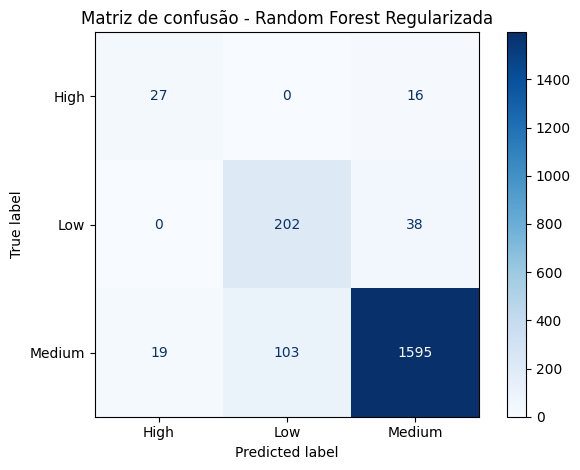

In [20]:
# Seleciona o melhor modelo pela métrica macro_f1, mais adequada ao desbalanceamento da base.
# Com os resultados atuais, o modelo selecionado é a Random Forest Regularizada.
best_model_name = results_df.iloc[0]['modelo']
best_model = trained_models[best_model_name]
print(f'Melhor modelo pelo macro_f1: {best_model_name}')

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title(f'Matriz de confusão - {best_model_name}')
plt.tight_layout()
plt.show()